In [166]:
import pandas as pd
import matplotlib.pyplot as plt

In [167]:
df = pd.read_csv('data/ab-test.csv')
df

,uid,diff,time,group
0,user_1,-103.333333,after,test
1,user_1,-6.000000,before,test
2,user_18,-10.000000,after,test
3,user_18,-3.500000,before,test
4,user_19,-82.333333,after,test
5,user_19,-148.000000,before,test
6,user_21,-78.500000,after,test
7,user_21,-112.500000,before,test
8,user_25,-127.500000,after,test
9,user_25,-69.333333,before,test


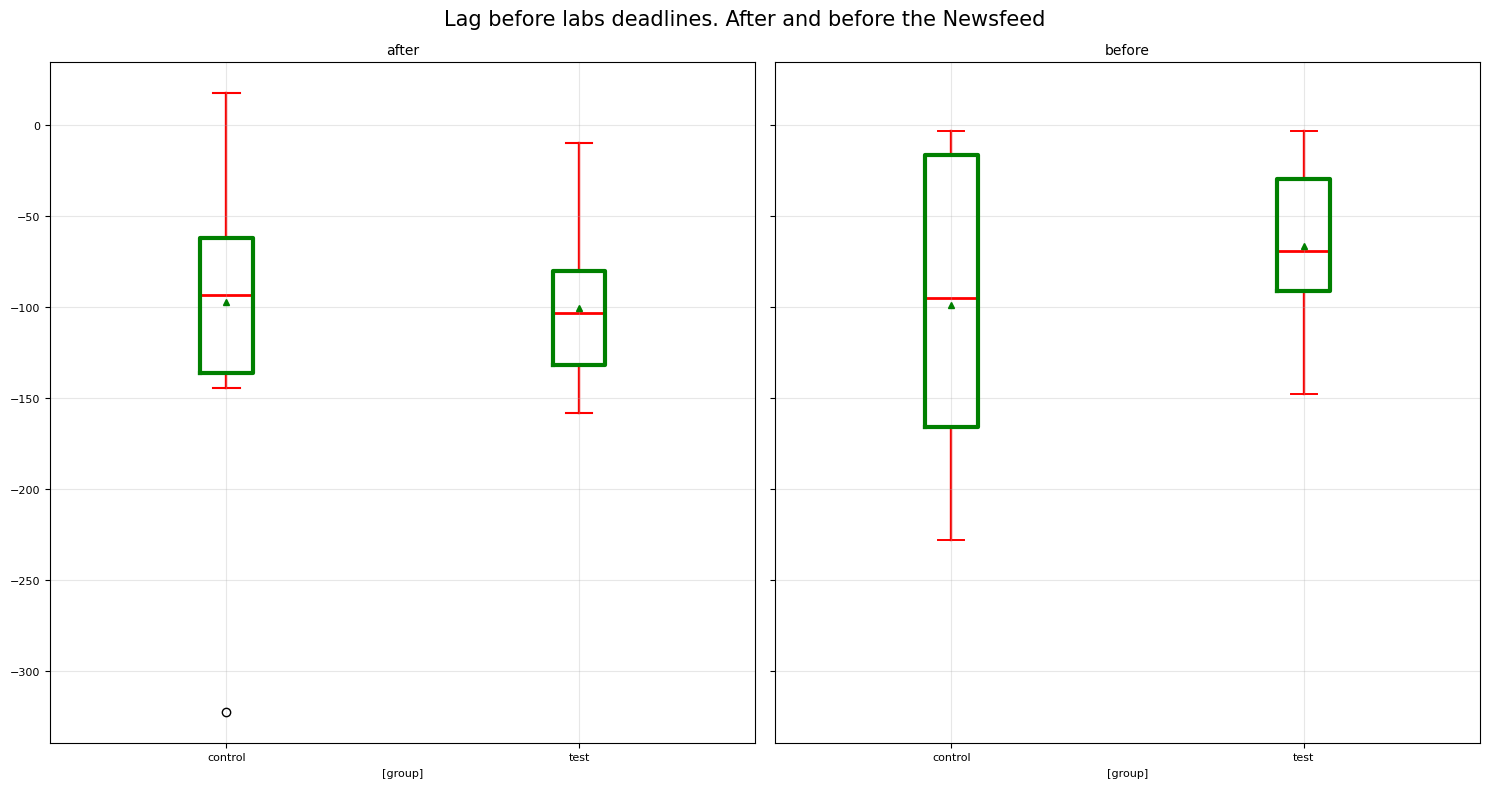

In [168]:
after_data = df[df['time'] == 'after']
before_data = df[df['time'] == 'before']

fig, axes = plt.subplots(1, 2, figsize=(15, 8), sharey=True)

after_control = after_data[after_data['group'] == 'control']['diff']
after_test = after_data[after_data['group'] == 'test']['diff']
bp1 = axes[0].boxplot([after_control, after_test], tick_labels=['control', 'test'],
                        boxprops=dict(color='green', linewidth=3, zorder=2),
                        medianprops=dict(color='red', linewidth=2, zorder=1),
                        whiskerprops=dict(color='red', linewidth=1.7, zorder=1),
                        capprops=dict(color='red', linewidth=1.5, zorder=1),
                        flierprops=dict(marker='o'))
axes[0].plot(bp1['medians'][0].get_xdata().mean(),  bp1['medians'][0].get_ydata().mean() - 4, marker='^', color='green', markersize=5)
axes[0].plot(bp1['medians'][1].get_xdata().mean(),  bp1['medians'][1].get_ydata().mean() + 3, marker='^', color='green', markersize=5)
axes[0].set_title('after', fontsize=10)
axes[0].set_xlabel('[group]', fontsize=8)
axes[0].tick_params(labelsize=8)
axes[0].grid(alpha=0.3)

before_control = before_data[before_data['group'] == 'control']['diff']
before_test = before_data[before_data['group'] == 'test']['diff']
bp2 = axes[1].boxplot([before_control, before_test], tick_labels=['control', 'test'],
                        boxprops=dict(color='green', linewidth=3, zorder=2),
                        medianprops=dict(color='red', linewidth=2, zorder=1),
                        whiskerprops=dict(color='red', linewidth=1.7, zorder=1),
                        capprops=dict(color='red', linewidth=1.4, zorder=1),
                        flierprops=dict(marker='o'))
axes[1].plot(bp2['medians'][0].get_xdata().mean(),  bp2['medians'][0].get_ydata().mean() - 4, marker='^', color='green', markersize=5)
axes[1].plot(bp2['medians'][1].get_xdata().mean(),  bp2['medians'][1].get_ydata().mean() + 3, marker='^', color='green', markersize=5)
axes[1].set_title('before', fontsize=10)
axes[1].set_xlabel('[group]', fontsize=8)
axes[1].tick_params(labelsize=8, labelleft=False)
axes[1].grid(alpha=0.3)

fig.suptitle('Lag before labs deadlines. After and before the Newsfeed', fontsize=15)
plt.tight_layout()
plt.show()

**Каков междквартильный размах контрольной группы до просмотра новостной ленты?**

**Ответ:** Судя по графику, он равен примерно 150.